In [1]:
# --- LIBRARIES ---

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# ------------------------------------------------------------------------------

In [2]:
# ---ALL SECTIONS DATA IMPORT ---

# Import data
route1 = np.load('route1.npz')
route2 = np.load('route2.npz')
route3 = np.load('route3.npz')
route4 = np.load('route4.npz')
route5 = np.load('route5.npz')
route6 = np.load('route6.npz')
route7 = np.load('route7.npz')
route8 = np.load('route8.npz')
route9 = np.load('route9.npz')
route10 = np.load('route10.npz')

# Concatenate GNN data
T_route_nearest = np.vstack((route1['Nearest_coordinates'],
                             route2['Nearest_coordinates'],
                             route3['Nearest_coordinates'],
                             route4['Nearest_coordinates'],
                             route5['Nearest_coordinates'],
                             route6['Nearest_coordinates'],
                             route7['Nearest_coordinates'],
                             route8['Nearest_coordinates'],
                             route9['Nearest_coordinates'],
                             route10['Nearest_coordinates']))

# Concatenate DDQN data
T_route_DDQN = np.vstack((route1['DDPG_coordinates'],
                          route2['DDPG_coordinates'],
                          route3['DDPG_coordinates'],
                          route4['DDPG_coordinates'],
                          route5['DDPG_coordinates'],
                          route6['DDPG_coordinates'],
                          route7['DDPG_coordinates'],
                          route8['DDPG_coordinates'],
                          route9['DDPG_coordinates'],
                          route10['DDPG_coordinates']))

# Concatenate 2Opt-DDQN data
T_route_2OPTDDQN = np.vstack((route1['2OPT-DDPG_coordinates'],
                               route2['2OPT-DDPG_coordinates'],
                               route3['2OPT-DDPG_coordinates'],
                               route4['2OPT-DDPG_coordinates'],
                               route5['2OPT-DDPG_coordinates'],
                               route6['2OPT-DDPG_coordinates'],
                               route7['2OPT-DDPG_coordinates'],
                               route8['2OPT-DDPG_coordinates'],
                               route9['2OPT-DDPG_coordinates'],
                               route10['2OPT-DDPG_coordinates']))

# ------------------------------------------------------------------------------

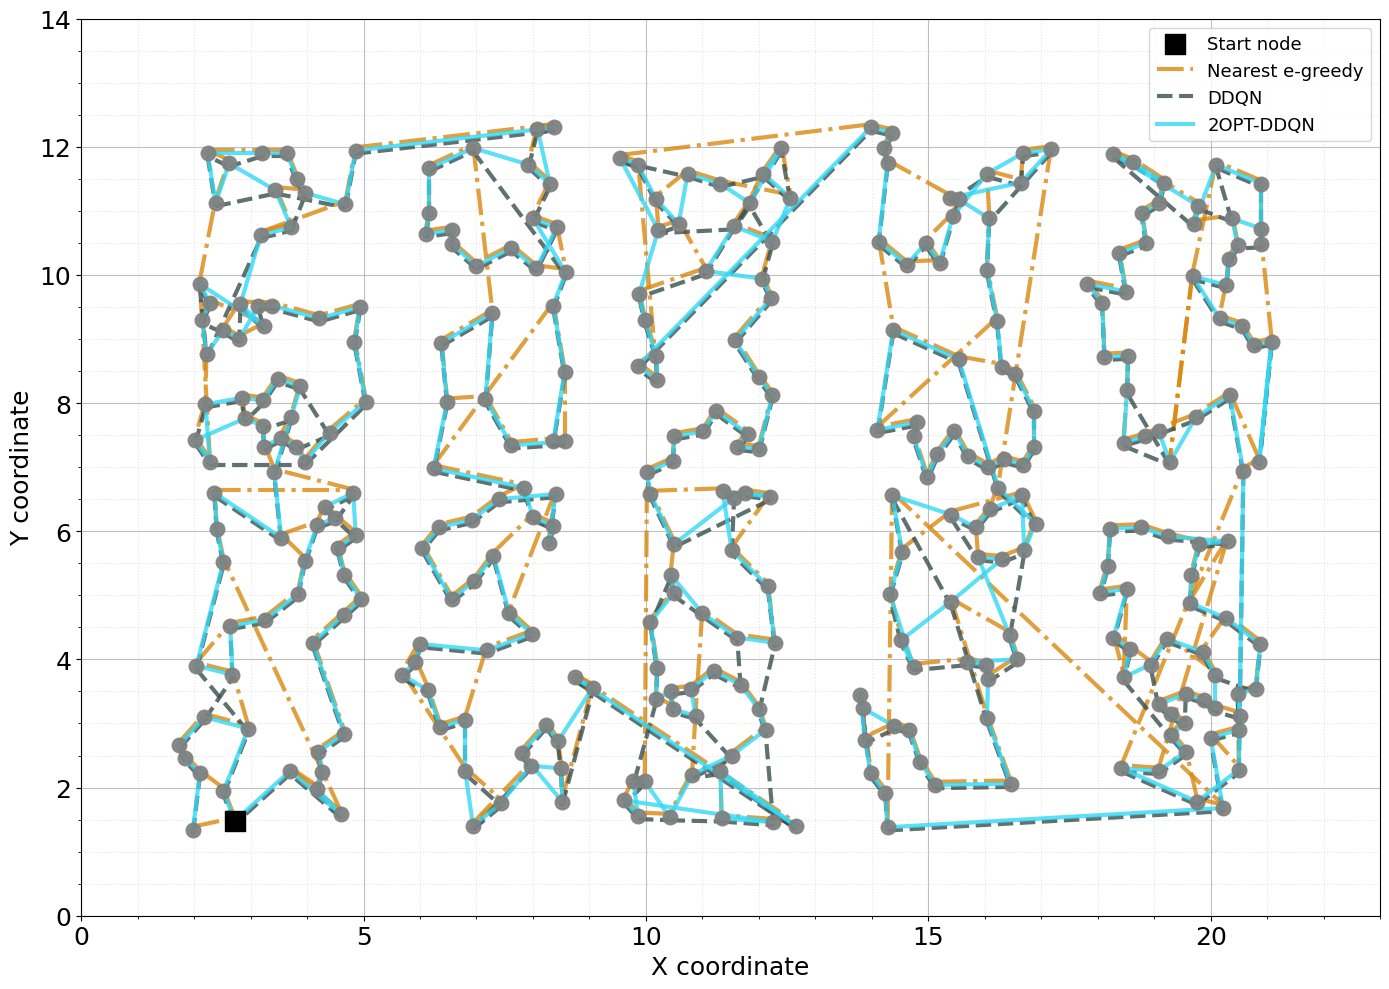

In [3]:
# --- COMPLETE ROUTE GRAPH ---

# Import original cluster data
coords = np.load('cluster_data.npy')

# Initialize figure
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# All clusters
ax.scatter(coords[:, 0], coords[:, 1], s=30, c="lightblue",
            alpha=0.7, edgecolors="black", linewidth=0.5)

# Start point
ax.scatter(coords[0, 0], coords[0, 1],
            s=200, c="black", marker="s", label=f"Start node", zorder=5)

# --- Greedy Nearest Neighbor Plot
for i in range(len(T_route_nearest) - 1):
    x1a, y1a = T_route_nearest[i]
    x2a, y2a = T_route_nearest[i + 1]
    ax.plot([x1a, x2a], [y1a+0.05, y2a+0.05], "-.", linewidth=3, alpha=0.8, color='#d98810')
ax.plot([x1a, x2a], [y1a+0.05, y2a+0.05], "-.", linewidth=3, alpha=0.8, label='Nearest e-greedy', color='#d98810')

# --- DDQN Plot
for i in range(len(T_route_DDQN) - 1):
    x1b, y1b = T_route_DDQN[i]
    x2b, y2b = T_route_DDQN[i + 1]
    ax.plot([x1b, x2b], [y1b-0.05, y2b-0.05], "--", linewidth=3, alpha=0.8, color='#384e4f')
ax.plot([x1b, x2b], [y1b-0.05, y2b-0.05], "--", linewidth=3, alpha=0.8, label='DDQN', color='#384e4f')

# --- 2Opt-DDQN Plot
for i in range(len(T_route_2OPTDDQN) - 1):
    x1c, y1c = T_route_2OPTDDQN[i]
    x2c, y2c = T_route_2OPTDDQN[i + 1]
    ax.plot([x1c, x2c], [y1c, y2c], "-", linewidth=3, alpha=0.8, color='#34d8f4')
ax.plot([x1c, x2c], [y1c, y2c], "-", linewidth=3, alpha=0.8, label='2OPT-DDQN', color='#34d8f4')

# Route nodes
route_coords = coords
ax.scatter(route_coords[:, 0], route_coords[:, 1], s=100, c="gray", linewidth=1.5, zorder=4, alpha=0.9)

ax.set_xlabel("X coordinate", fontsize=18)
ax.set_ylabel("Y coordinate", fontsize=18)
ax.set_xlim(0, 23)
ax.set_ylim(0, 14)
ax.legend(fontsize=13)
ax.grid(True, alpha=0.8)
ax.minorticks_on()
ax.grid(visible=True, which='minor', color='gray', linestyle=':', alpha=0.2)
ax.tick_params(axis='both', labelsize=18)
plt.tight_layout()
plt.savefig("route_total.svg", bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------------------

In [4]:
# --- TOTAL DISTANCE COMPARISON ---

# Distance function
def total_dist(coordinates):

    points = np.array(coordinates)
    diff = np.diff(points, axis=0)
    dist_segments = np.sqrt(np.sum(diff**2, axis=1))

    return np.sum(dist_segments)

# Print results
print("\n--- TOTAL path using 'nearest' strategy ---")
print(f"Nearest TOTAL distance found: {total_dist(T_route_nearest):.2f} meters")

print("\n--- TOTAL path using DDQN strategy ---")
print(f"DDQN TOTAL distance found: {total_dist(T_route_DDQN):.2f} meters")

print("\n--- TOTAL path using 2_OPT-DDQN strategy ---")
print(f"2OPT-DDQN TOTAL distance found: {total_dist(T_route_2OPTDDQN):.1f} meters")

# ------------------------------------------------------------------------------


--- TOTAL path using 'nearest' strategy ---
Nearest TOTAL distance found: 266.84 meters

--- TOTAL path using DDQN strategy ---
DDQN TOTAL distance found: 249.71 meters

--- TOTAL path using 2_OPT-DDQN strategy ---
2OPT-DDQN TOTAL distance found: 241.1 meters


In [ ]:
# --- TRAINING COMPARISON FOR EACH SECTION ---

# Import reward data
reward1 = route1['reward']
reward2 = route2['reward']
reward3 = route3['reward']
reward4 = route4['reward']
reward5 = route5['reward']
reward6 = route6['reward']
reward7 = route7['reward']
reward8 = route8['reward']
reward9 = route9['reward']
reward10 = route10['reward']

# Import distance data
dist1 = route1['distance']
dist2 = route2['distance']
dist3 = route3['distance']
dist4 = route4['distance']
dist5 = route5['distance']
dist6 = route6['distance']
dist7 = route7['distance']
dist8 = route8['distance']
dist9 = route9['distance']
dist10 = route10['distance']

# Initialize figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- Comparison distance plot
ax1.plot(np.convolve(dist1, np.ones(50)/50, mode="valid"),
          color="#006BA4", linewidth=2, label="Distance sec (0, 0)")
ax1.plot(np.convolve(dist2, np.ones(50)/50, mode="valid"),
          color="#FF800E", linewidth=2, label="Distance sec (1, 0)")
ax1.plot(np.convolve(dist3, np.ones(50)/50, mode="valid"),
          color="#ABABAB", linewidth=2, label="Distance sec (1, 1)")
ax1.plot(np.convolve(dist4, np.ones(50)/50, mode="valid"),
          color="#C85200", linewidth=2, label="Distance sec (0, 1)")
ax1.plot(np.convolve(dist5, np.ones(50)/50, mode="valid"),
          color="#595959", linewidth=2, label="Distance sec (0, 2)")
ax1.plot(np.convolve(dist6, np.ones(50)/50, mode="valid"),
          color="#5F9ED1", linewidth=2, label="Distance sec (1, 2)")
ax1.plot(np.convolve(dist7, np.ones(50)/50, mode="valid"),
          color="#C85200", linewidth=2, label="Distance sec (1, 3)")
ax1.plot(np.convolve(dist8, np.ones(50)/50, mode="valid"),
          color="#898989", linewidth=2, label="Distance sec (0, 3)")
ax1.plot(np.convolve(dist9, np.ones(50)/50, mode="valid"),
          color="#A2C8EC", linewidth=2, label="Distance sec (0, 4)")
ax1.plot(np.convolve(dist10, np.ones(50)/50, mode="valid"),
          color="#FFBC79", linewidth=2, label="Distance sec (1, 4)")
ax1.set_xlabel("Episode", fontsize=18)
ax1.set_ylabel("Total distance", fontsize=18)
ax1.legend()
ax1.grid(True)
ax1.minorticks_on()
ax1.grid(visible=True, which='minor', color='gray', linestyle=':', alpha=0.2)
ax1.tick_params(axis='both', labelsize=18)
ax1.set_xlim(0, 5000)
ax1.legend(fontsize=14)

# --- Comparison reward plot
ax2.plot(np.convolve(reward1, np.ones(50)/50, mode="valid"),
          color="#006BA4", linewidth=2, label="Avg. reward sec (0, 0)")
ax2.plot(np.convolve(reward2, np.ones(50)/50, mode="valid"),
          color="#FF800E", linewidth=2, label="Avg. reward sec (1, 0)")
ax2.plot(np.convolve(reward3, np.ones(50)/50, mode="valid"),
          color="#ABABAB", linewidth=2, label="Avg. reward sec (1, 1)")
ax2.plot(np.convolve(reward4, np.ones(50)/50, mode="valid"),
          color="#C85200", linewidth=2, label="Avg. reward sec (0, 1)")
ax2.plot(np.convolve(reward5, np.ones(50)/50, mode="valid"),
          color="#595959", linewidth=2, label="Avg. reward sec (0, 2)")
ax2.plot(np.convolve(reward6, np.ones(50)/50, mode="valid"),
          color="#5F9ED1", linewidth=2, label="Avg. reward sec (1, 2)")
ax2.plot(np.convolve(reward7, np.ones(50)/50, mode="valid"),
          color="#C85200", linewidth=2, label="Avg. reward sec (1, 3)")
ax2.plot(np.convolve(reward8, np.ones(50)/50, mode="valid"),
          color="#898989", linewidth=2, label="Avg. reward sec (0, 3)")
ax2.plot(np.convolve(reward9, np.ones(50)/50, mode="valid"),
          color="#A2C8EC", linewidth=2, label="Avg. reward sec (0, 4)")
ax2.plot(np.convolve(reward10, np.ones(50)/50, mode="valid"),
          color="#FFBC79", linewidth=2, label="Avg. reward sec (1, 4)")
ax2.set_xlabel("Episode", fontsize=18)
ax2.set_ylabel("Total reward", fontsize=18)
ax2.legend()
ax2.grid(True)
ax2.minorticks_on()
ax2.grid(visible=True, which='minor', color='gray', linestyle=':', alpha=0.2)
ax2.tick_params(axis='both', labelsize=18)
ax2.set_xlim(0, 5000)
ax2.legend(fontsize=14)
plt.savefig("figure.svg", bbox_inches='tight')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------

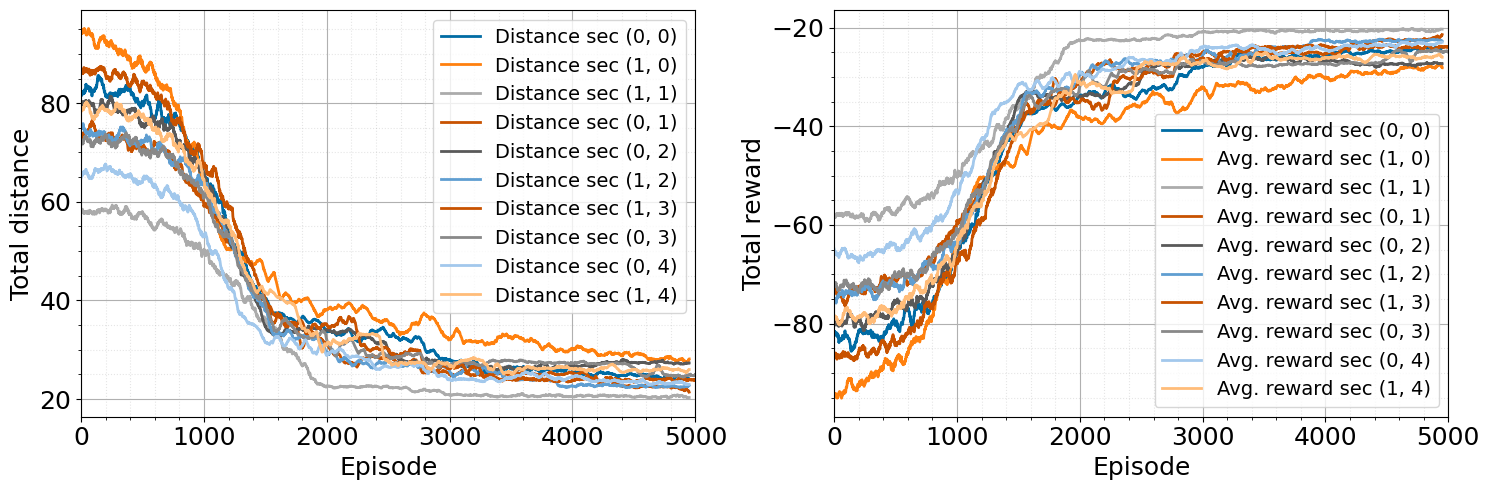

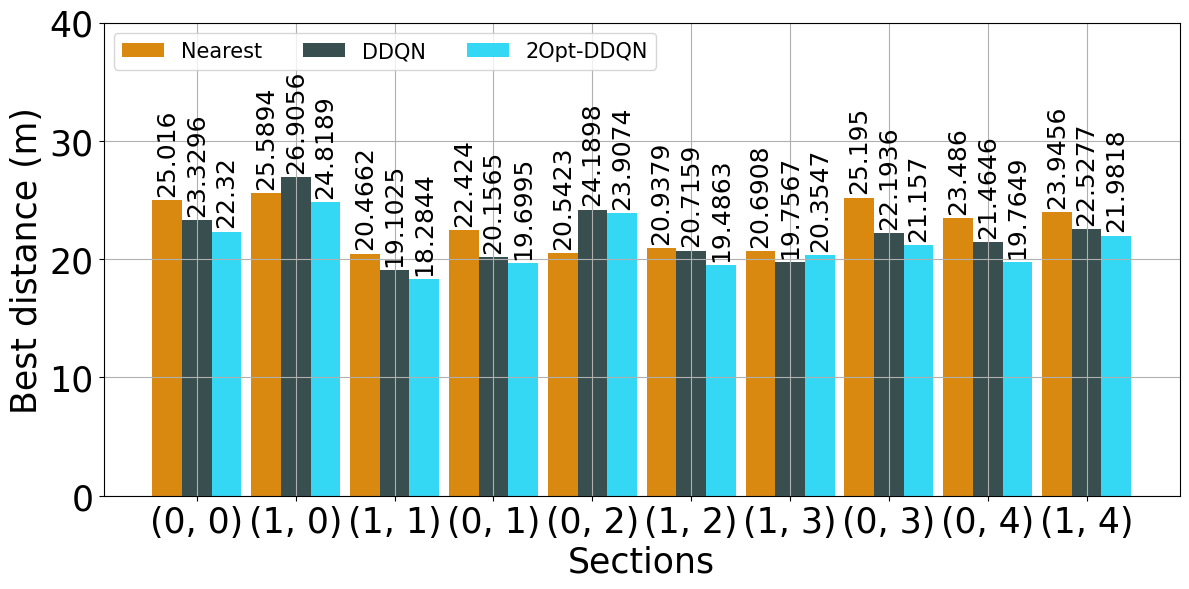

In [ ]:
# --- FINAL DISTANCE COMPARISON FOR ALL SECTIONS ---

# Figure data distribution
sections = ("(0, 0)", "(1, 0)", "(1, 1)", "(0, 1)", "(0, 2)", "(1, 2)", "(1, 3)", "(0, 3)", "(0, 4)", "(1, 4)")

agents_means = {
    'Nearest': (route1['Nearest_dist'], route2['Nearest_dist'], route3['Nearest_dist'], route4['Nearest_dist'], route5['Nearest_dist'],
                route6['Nearest_dist'], route7['Nearest_dist'], route8['Nearest_dist'], route9['Nearest_dist'], route10['Nearest_dist']),
    'DDQN': (route1['DDPG_dist'], route2['DDPG_dist'], route3['DDPG_dist'], route4['DDPG_dist'], route5['DDPG_dist'],
             route6['DDPG_dist'], route7['DDPG_dist'], route8['DDPG_dist'], route9['DDPG_dist'], route10['DDPG_dist']),
    '2Opt-DDQN': (route1['2OPT-DDPG_dist'], route2['2OPT-DDPG_dist'], route3['2OPT-DDPG_dist'], route4['2OPT-DDPG_dist'], route5['2OPT-DDPG_dist'],
                  route6['2OPT-DDPG_dist'], route7['2OPT-DDPG_dist'], route8['2OPT-DDPG_dist'], route9['2OPT-DDPG_dist'], route10['2OPT-DDPG_dist']),
}

x = np.arange(len(sections))  # the label locations
width = 0.3  # the width of the bars
multiplier = 0

# Initialize figure
fig, (ax) = plt.subplots(1, 1, figsize=(12, 6))
ax.grid(True)

for attribute, measurement in agents_means.items():

    if attribute == 'Nearest':
        color = '#d98810'
    elif attribute == 'DDQN':
        color = '#384e4f'
    else:
        color = '#34d8f4'

    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute, color=color)
    ax.bar_label(rects, padding=3, rotation=90, fontsize=18)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Best distance (m)', fontsize = 25)
ax.set_xlabel('Sections', fontsize = 25)
ax.set_xticks(x + width, sections)
ax.tick_params(axis='both', labelsize=25)

ax.legend(loc='upper left', ncols=3, fontsize=15)
ax.set_ylim(0, 40)

plt.savefig("distances.svg", bbox_inches='tight')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------